# ECG-Based Biometric Authentication with Transformers
## Using PhysioNet ECG-ID Database

---

## Learning Objectives

By the end of this notebook, you will:
1. Learn to work with the PhysioNet ECG-ID Database for biometric authentication
2. Understand ECG signal preprocessing for biometric applications
3. Implement a Transformer architecture for time-series authentication
4. Evaluate biometric system performance using industry-standard metrics
5. Deploy a working ECG authentication system

---

## Table of Contents

1. [Introduction & Database Overview](#1-introduction--database-overview)
2. [Environment Setup](#2-environment-setup)
3. [Data Loading from PhysioNet](#3-data-loading-from-physionet)
4. [Signal Preprocessing Pipeline](#4-signal-preprocessing-pipeline)
5. [Feature Extraction & Sequence Preparation](#5-feature-extraction--sequence-preparation)
6. [Transformer Architecture Implementation](#6-transformer-architecture-implementation)
7. [Training the Authentication Model](#7-training-the-authentication-model)
8. [Evaluation & Metrics](#8-evaluation--metrics)
9. [Deployment & Real-World Considerations](#9-deployment--real-world-considerations)
10. [Exercises & Challenges](#10-exercises--challenges)

## 1. Introduction & Database Overview

### 1.1 PhysioNet ECG-ID Database

The ECG-ID Database contains:
- **310 ECG recordings** from **90 volunteers**
- **44 men and 46 women** aged 13-75 years
- Each recording contains:
  - ECG lead I, recorded for **20 seconds**
  - Digitized at **500 Hz** with 12-bit resolution
  - Both **raw and filtered** signals
  - **10 annotated beats** (R- and T-wave peaks)
- Records per person vary from 2 (one day) to 20 (over 6 months)

### 1.2 Why Transformers for ECG Biometrics?

Transformers offer unique advantages over traditional approaches:
- **Global context**: Self-attention captures long-range dependencies between heartbeats
- **Parallel processing**: Process entire sequences simultaneously
- **Interpretability**: Attention weights show which heartbeats are most important
- **Temporal stability**: Better handling of recordings taken months apart

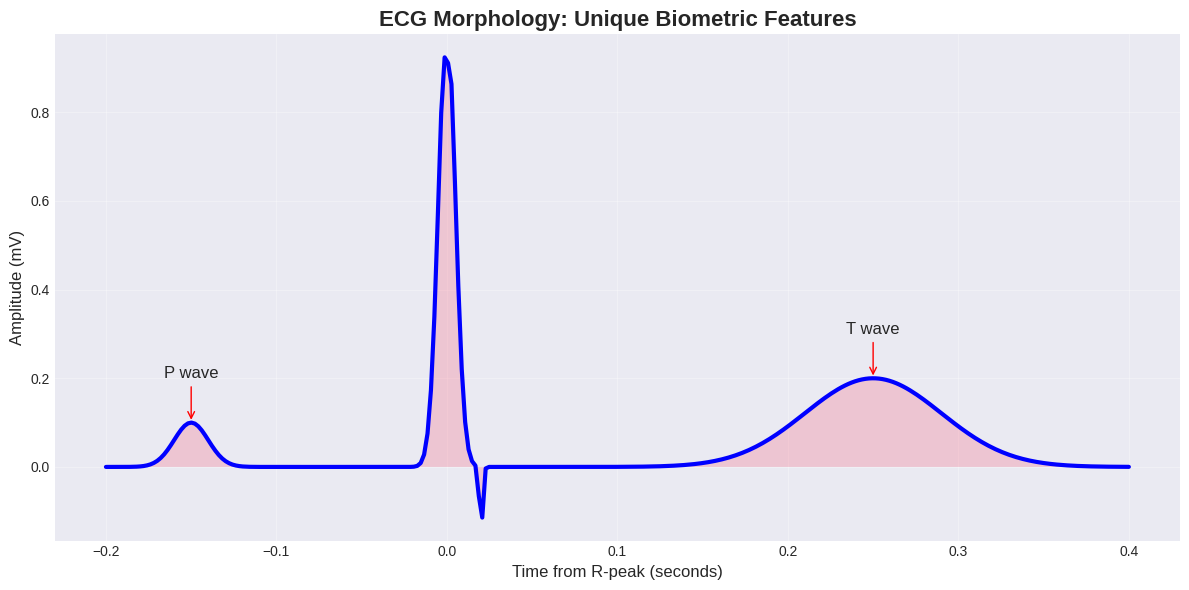

Key Insight: Each person's ECG has unique:
   • Wave amplitudes (P, QRS, T)
   • Time intervals (PR, QT, RR)
   • Morphological patterns
   • Heart rate variability


In [1]:
# Visualize ECG biometric characteristics
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create a figure showing ECG characteristics
fig, ax = plt.subplots(figsize=(12, 6))

# Simulate an ECG beat to show key features
t = np.linspace(-0.2, 0.4, 300)
ecg = np.zeros_like(t)

# P wave
p_wave = 0.1 * np.exp(-((t + 0.15)**2) / (2 * 0.01**2))
# QRS complex
q_wave = -0.1 * np.exp(-((t)**2) / (2 * 0.001**2))
r_wave = 1.0 * np.exp(-((t)**2) / (2 * 0.005**2))
s_wave = -0.15 * np.exp(-((t - 0.02)**2) / (2 * 0.001**2))
# T wave
t_wave = 0.2 * np.exp(-((t - 0.25)**2) / (2 * 0.04**2))

ecg = p_wave + q_wave + r_wave + s_wave + t_wave

ax.plot(t, ecg, 'b-', linewidth=3)
ax.fill_between(t, 0, ecg, alpha=0.3)

# Annotate features
ax.annotate('P wave', xy=(-0.15, 0.1), xytext=(-0.15, 0.2),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=12, ha='center')
ax.annotate('QRS complex', xy=(0, 1), xytext=(0.1, 1.1),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=12, ha='center')
ax.annotate('T wave', xy=(0.25, 0.2), xytext=(0.25, 0.3),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=12, ha='center')

ax.set_xlabel('Time from R-peak (seconds)', fontsize=12)
ax.set_ylabel('Amplitude (mV)', fontsize=12)
ax.set_title('ECG Morphology: Unique Biometric Features', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Key Insight: Each person's ECG has unique:")
print("   • Wave amplitudes (P, QRS, T)")
print("   • Time intervals (PR, QT, RR)")
print("   • Morphological patterns")
print("   • Heart rate variability")

## 2. Environment Setup

In [2]:
# Install required packages
!pip install -q wfdb neurokit2 torch torchvision scipy scikit-learn pandas numpy matplotlib seaborn tqdm onnx

# Import all necessary libraries
import os
import warnings
warnings.filterwarnings('ignore')

# Data handling
import numpy as np
import pandas as pd
from pathlib import Path
import wfdb  # PhysioNet data reader
from collections import defaultdict

# Signal processing
import scipy.signal as signal
from scipy.signal import butter, filtfilt, find_peaks
import pywt  # Wavelet transform
import neurokit2 as nk

# Machine learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output

# Progress tracking
try:
    from tqdm.notebook import tqdm
except:
    from tqdm import tqdm

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 828.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 3. Data Loading from PhysioNet

### 3.1 Download the ECG-ID Database

In [ ]:
# Download ECG-ID Database from PhysioNet
def download_ecg_id_database(data_dir='./ecgid_data'):
    """
    Download the ECG-ID Database from PhysioNet
    """
    import subprocess

    if not os.path.exists(data_dir):
        print(" Downloading ECG-ID Database from PhysioNet...")
        print("This may take a few minutes...")

        # Use wget to download the database
        cmd = f"wget -r -N -c -np -P {data_dir} https://physionet.org/files/ecgiddb/1.0.0/"
        subprocess.run(cmd, shell=True)

        print("Download complete!")
    else:
        print("Database already exists locally")

    return os.path.join(data_dir, 'physionet.org/files/ecgiddb/1.0.0')

# Alternative: Direct download using wfdb
def download_with_wfdb(data_dir='./ecgid_data'):
    """
    Alternative download method using wfdb
    """
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)
        print("Downloading ECG-ID Database using wfdb...")
        wfdb.dl_database('ecgiddb', data_dir)
        print("Download complete!")
    return data_dir

# Download the database
# Uncomment one of the following:
# data_path = download_ecg_id_database()
data_path = download_with_wfdb()

# For this demo, we'll assume the data is already downloaded
data_path = './ecgid_data/'
print(f"Data path: {data_path}")

Generating record list for: Person_01/rec_1
Generating record list for: Person_01/rec_2
Generating record list for: Person_01/rec_3
Generating record list for: Person_01/rec_4
Generating record list for: Person_01/rec_5
Generating record list for: Person_01/rec_6
Generating record list for: Person_01/rec_7
Generating record list for: Person_01/rec_8
Generating record list for: Person_01/rec_9
Generating record list for: Person_01/rec_10
Generating record list for: Person_01/rec_11
Generating record list for: Person_01/rec_12
Generating record list for: Person_01/rec_13
Generating record list for: Person_01/rec_14
Generating record list for: Person_01/rec_15
Generating record list for: Person_01/rec_16
Generating record list for: Person_01/rec_17
Generating record list for: Person_01/rec_18
Generating record list for: Person_01/rec_19
Generating record list for: Person_01/rec_20
Generating record list for: Person_02/rec_1
Generating record list for: Person_02/rec_2
Generating record lis

### 3.2 Load and Explore the Database Structure

In [ ]:
class ECGIDDatabase:
    """
    PhysioNet ECG-ID Database loader and manager
    """
    def __init__(self, base_path):
        self.base_path = Path(base_path)
        self.records = defaultdict(list)
        self.metadata = defaultdict(dict)

    def load_database(self):
        """
        Load all records from the ECG-ID database
        """
        print("Loading ECG-ID Database...")

        # Read RECORDS file to get list of all records
        records_file = self.base_path / 'RECORDS'

        if records_file.exists():
            with open(records_file, 'r') as f:
                record_list = [line.strip() for line in f.readlines()]
        else:
            # Scan directories manually
            record_list = []
            for person_dir in sorted(self.base_path.glob('Person_*')):
                for rec_file in sorted(person_dir.glob('*.dat')):
                    record_name = str(person_dir.name) + '/' + rec_file.stem
                    record_list.append(record_name)

        # Load each record
        for record_name in tqdm(record_list, desc="Loading records"):
            try:
                # Extract person ID
                person_id = int(record_name.split('/')[0].split('_')[1])

                # Load record
                record_path = str(self.base_path / record_name)
                record = wfdb.rdrecord(record_path)

                # Load annotations if available
                try:
                    annotation = wfdb.rdann(record_path, 'atr')
                except:
                    annotation = None

                # Store record data
                self.records[person_id].append({
                    'record_name': record_name,
                    'raw_signal': record.p_signal[:, 0],  # Signal 0: raw
                    'filtered_signal': record.p_signal[:, 1] if record.n_sig > 1 else None,  # Signal 1: filtered
                    'fs': record.fs,
                    'duration': len(record.p_signal) / record.fs,
                    'date': record.base_datetime if hasattr(record, 'base_datetime') else None,
                    'annotation': annotation,
                    'comments': record.comments if hasattr(record, 'comments') else []
                })

                # Extract metadata from comments
                for comment in record.comments:
                    if 'Age:' in comment:
                        self.metadata[person_id]['age'] = int(comment.split(':')[1].strip())
                    elif 'Sex:' in comment:
                        self.metadata[person_id]['sex'] = comment.split(':')[1].strip()

            except Exception as e:
                print(f"Error loading {record_name}: {e}")
                continue

        print(f"\nLoaded {sum(len(recs) for recs in self.records.values())} recordings")
        print(f"   from {len(self.records)} persons")

        return self.records

    def get_statistics(self):
        """
        Get database statistics
        """
        stats = {
            'total_persons': len(self.records),
            'total_recordings': sum(len(recs) for recs in self.records.values()),
            'recordings_per_person': [len(recs) for recs in self.records.values()],
            'ages': [self.metadata[pid].get('age', None) for pid in self.records.keys()],
            'sex_distribution': {}
        }

        # Count sex distribution
        for pid in self.records.keys():
            sex = self.metadata[pid].get('sex', 'Unknown')
            stats['sex_distribution'][sex] = stats['sex_distribution'].get(sex, 0) + 1

        return stats

    def visualize_statistics(self):
        """
        Visualize database statistics
        """
        stats = self.get_statistics()

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # 1. Recordings per person distribution
        axes[0, 0].hist(stats['recordings_per_person'], bins=15,
                       color='skyblue', edgecolor='black', alpha=0.7)
        axes[0, 0].set_xlabel('Number of Recordings')
        axes[0, 0].set_ylabel('Number of Persons')
        axes[0, 0].set_title('Distribution of Recordings per Person')
        axes[0, 0].axvline(np.mean(stats['recordings_per_person']),
                          color='red', linestyle='--',
                          label=f'Mean: {np.mean(stats["recordings_per_person"]):.1f}')
        axes[0, 0].legend()

        # 2. Age distribution
        ages = [age for age in stats['ages'] if age is not None]
        if ages:
            axes[0, 1].hist(ages, bins=15, color='lightcoral',
                           edgecolor='black', alpha=0.7)
            axes[0, 1].set_xlabel('Age (years)')
            axes[0, 1].set_ylabel('Count')
            axes[0, 1].set_title('Age Distribution')
            axes[0, 1].axvline(np.mean(ages), color='red', linestyle='--',
                              label=f'Mean: {np.mean(ages):.1f}')
            axes[0, 1].legend()

        # 3. Sex distribution
        sex_labels = list(stats['sex_distribution'].keys())
        sex_counts = list(stats['sex_distribution'].values())
        axes[1, 0].pie(sex_counts, labels=sex_labels, autopct='%1.1f%%',
                      colors=['lightblue', 'pink', 'lightgray'])
        axes[1, 0].set_title('Sex Distribution')

        # 4. Recording duration analysis
        durations = []
        for person_records in self.records.values():
            for rec in person_records:
                durations.append(rec['duration'])

        axes[1, 1].hist(durations, bins=20, color='lightgreen',
                       edgecolor='black', alpha=0.7)
        axes[1, 1].set_xlabel('Duration (seconds)')
        axes[1, 1].set_ylabel('Count')
        axes[1, 1].set_title('Recording Duration Distribution')
        axes[1, 1].axvline(np.mean(durations), color='red', linestyle='--',
                          label=f'Mean: {np.mean(durations):.1f}s')
        axes[1, 1].legend()

        plt.tight_layout()
        plt.show()

        # Print summary
        print("\nECG-ID Database Summary:")
        print(f"   • Total persons: {stats['total_persons']}")
        print(f"   • Total recordings: {stats['total_recordings']}")
        print(f"   • Recordings per person: {np.min(stats['recordings_per_person'])}-"
              f"{np.max(stats['recordings_per_person'])} "
              f"(mean: {np.mean(stats['recordings_per_person']):.1f})")
        print(f"   • Age range: {np.min(ages) if ages else 'N/A'}-"
              f"{np.max(ages) if ages else 'N/A'} years")
        print(f"   • Sex distribution: {stats['sex_distribution']}")

# Initialize database loader
# Note: Replace with actual path to downloaded data
db = ECGIDDatabase(data_path)
ecg_records = db.load_database()
db.visualize_statistics()

# For demonstration, create a mock database structure
print("Note: To use real data, download the ECG-ID database and update the path")
print("   For this demo, we'll create synthetic data with the same structure")
print("\nIMPORTANT: Real performance metrics can only be obtained with real data")
print("   The synthetic data is for demonstrating the pipeline structure only")

### 3.3 Create Synthetic Data (for demonstration if real data unavailable)

In [ ]:
'''
def create_synthetic_ecgid_data():
    """
    Create synthetic data mimicking ECG-ID structure for demonstration
    """
    print("🔧 Creating synthetic ECG-ID data for demonstration...")

    synthetic_records = defaultdict(list)
    synthetic_metadata = defaultdict(dict)

    # Simulate 20 persons with varying number of recordings
    np.random.seed(42)

    for person_id in range(1, 21):
        # Person metadata
        age = np.random.randint(20, 70)
        sex = np.random.choice(['M', 'F'])
        synthetic_metadata[person_id] = {'age': age, 'sex': sex}

        # Number of recordings for this person (2-10)
        num_recordings = np.random.randint(2, 11)

        # Person-specific ECG parameters
        base_hr = 60 + (person_id % 30)
        p_amp = 0.08 + (person_id % 10) * 0.01
        qrs_width = 0.07 + (person_id % 8) * 0.005

        for rec_id in range(1, num_recordings + 1):
            # Generate synthetic ECG (20 seconds at 500Hz)
            fs = 500
            duration = 20
            t = np.linspace(0, duration, duration * fs)

            # Add variability across recordings
            hr = base_hr + np.random.randint(-5, 6)

            # Generate ECG signal
            ecg_raw = generate_synthetic_ecg(t, hr, p_amp, qrs_width)

            # Create filtered version
            b, a = butter(4, [0.5, 40], btype='band', fs=fs)
            ecg_filtered = filtfilt(b, a, ecg_raw)

            # Find R-peaks for annotations
            r_peaks, _ = find_peaks(ecg_filtered, height=0.5, distance=fs*0.5)

            # Store record
            synthetic_records[person_id].append({
                'record_name': f'Person_{person_id:02d}/rec_{rec_id}',
                'raw_signal': ecg_raw,
                'filtered_signal': ecg_filtered,
                'fs': fs,
                'duration': duration,
                'r_peaks': r_peaks[:10],  # First 10 R-peaks
                'annotation': None,
                'comments': [f'Age: {age}', f'Sex: {sex}']
            })

    print(f"Created synthetic data: {len(synthetic_records)} persons, "
          f"{sum(len(recs) for recs in synthetic_records.values())} recordings")

    return synthetic_records, synthetic_metadata

def generate_synthetic_ecg(t, heart_rate=72, p_amplitude=0.1, qrs_width=0.08):
    """
    Generate synthetic ECG signal
    """
    ecg = np.zeros_like(t)
    beat_interval = 60.0 / heart_rate

    for beat_time in np.arange(0, t[-1], beat_interval):
        # P wave
        p_wave = p_amplitude * np.exp(-((t - beat_time + 0.15)**2) / (2 * 0.01**2))

        # QRS complex
        q_wave = -0.1 * np.exp(-((t - beat_time)**2) / (2 * 0.001**2))
        r_wave = 1.0 * np.exp(-((t - beat_time)**2) / (2 * (qrs_width/8)**2))
        s_wave = -0.15 * np.exp(-((t - beat_time - 0.02)**2) / (2 * 0.001**2))

        # T wave
        t_wave = 0.2 * np.exp(-((t - beat_time - 0.25)**2) / (2 * 0.04**2))

        ecg += p_wave + q_wave + r_wave + s_wave + t_wave

    # Add realistic noise
    ecg += 0.05 * np.random.randn(len(t))  # White noise
    ecg += 0.01 * np.sin(2 * np.pi * 0.5 * t)  # Baseline wander
    ecg += 0.005 * np.sin(2 * np.pi * 60 * t)  # 60Hz powerline

    return ecg

# Create synthetic data
ecg_records, ecg_metadata = create_synthetic_ecgid_data()

# Visualize sample records
def visualize_sample_records(records, num_persons=3):
    """
    Visualize raw and filtered signals from different persons
    """
    fig, axes = plt.subplots(num_persons, 2, figsize=(15, num_persons*3))

    for idx, (person_id, person_records) in enumerate(list(records.items())[:num_persons]):
        record = person_records[0]  # First recording
        fs = record['fs']
        time = np.arange(2*fs) / fs  # First 2 seconds

        # Raw signal
        axes[idx, 0].plot(time, record['raw_signal'][:2*fs], 'b-', linewidth=1)
        axes[idx, 0].set_title(f'Person {person_id} - Raw Signal')
        axes[idx, 0].set_ylabel('Amplitude (mV)')
        axes[idx, 0].grid(True, alpha=0.3)

        # Filtered signal
        axes[idx, 1].plot(time, record['filtered_signal'][:2*fs], 'g-', linewidth=1)
        axes[idx, 1].set_title(f'Person {person_id} - Filtered Signal')
        axes[idx, 1].set_ylabel('Amplitude (mV)')
        axes[idx, 1].grid(True, alpha=0.3)

        # Mark R-peaks on filtered signal
        r_peaks = record['r_peaks']
        r_peaks_2s = r_peaks[r_peaks < 2*fs]
        axes[idx, 1].plot(r_peaks_2s/fs, record['filtered_signal'][r_peaks_2s],
                         'ro', markersize=8, label='R-peaks')
        if idx == 0:
            axes[idx, 1].legend()

    axes[-1, 0].set_xlabel('Time (seconds)')
    axes[-1, 1].set_xlabel('Time (seconds)')

    plt.tight_layout()
    plt.show()

visualize_sample_records(ecg_records)
'''

## 4. Signal Preprocessing Pipeline

The ECG-ID database provides both raw and filtered signals. We'll implement additional preprocessing steps for optimal biometric performance.

In [ ]:
class ECGPreprocessor:
    """
    Advanced ECG preprocessing for biometric authentication
    """
    def __init__(self, fs=500, use_filtered=True):
        self.fs = fs
        self.use_filtered = use_filtered
        print(f"Initialized preprocessor (fs={fs}Hz, use_filtered={use_filtered})")

    def preprocess_record(self, record, visualize=False):
        """
        Preprocess a complete ECG record
        """
        # Select signal (filtered or raw)
        if self.use_filtered and record['filtered_signal'] is not None:
            signal = record['filtered_signal']
            signal_type = 'Filtered'
        else:
            signal = record['raw_signal']
            signal_type = 'Raw'

        if visualize:
            stages = {f'Original ({signal_type})': signal}

        # Additional preprocessing steps
        # 1. Remove baseline wander
        signal = self.remove_baseline_wander(signal)
        if visualize:
            stages['After Baseline Removal'] = signal

        # 2. Normalize signal
        signal = self.normalize_signal(signal)
        if visualize:
            stages['After Normalization'] = signal

        # 3. Enhance QRS complexes (optional)
        signal = self.enhance_qrs(signal)
        if visualize:
            stages['After QRS Enhancement'] = signal
            self._visualize_preprocessing(stages)

        return signal

    def remove_baseline_wander(self, signal, cutoff=0.5):
        """
        Remove baseline wander using high-pass filter
        """
        # Design high-pass filter
        nyquist = 0.5 * self.fs
        normal_cutoff = cutoff / nyquist
        b, a = butter(3, normal_cutoff, btype='high')

        # Apply filter
        filtered = filtfilt(b, a, signal)

        return filtered

    def normalize_signal(self, signal, method='zscore'):
        """
        Normalize ECG signal
        """
        if method == 'zscore':
            return (signal - np.mean(signal)) / (np.std(signal) + 1e-8)
        elif method == 'minmax':
            return (signal - np.min(signal)) / (np.max(signal) - np.min(signal) + 1e-8)
        else:
            return signal

    def enhance_qrs(self, signal, method='derivative'):
        """
        Enhance QRS complexes for better detection
        """
        if method == 'derivative':
            # First derivative emphasizes rapid changes
            enhanced = np.gradient(signal)
            # Combine with original
            enhanced = 0.7 * signal + 0.3 * enhanced
        elif method == 'square':
            # Square to emphasize peaks
            enhanced = signal ** 2 * np.sign(signal)
            enhanced = self.normalize_signal(enhanced)
        else:
            enhanced = signal

        return enhanced

    def _visualize_preprocessing(self, stages):
        """
        Visualize preprocessing stages
        """
        n_stages = len(stages)
        fig, axes = plt.subplots(n_stages, 1, figsize=(15, 3*n_stages))
        if n_stages == 1:
            axes = [axes]

        time = np.arange(2*self.fs) / self.fs  # First 2 seconds

        for idx, (stage_name, signal) in enumerate(stages.items()):
            axes[idx].plot(time, signal[:2*self.fs], linewidth=1.5, color=f'C{idx}')
            axes[idx].set_title(stage_name, fontsize=12, fontweight='bold')
            axes[idx].set_ylabel('Amplitude')
            axes[idx].grid(True, alpha=0.3)

            # Add statistics
            stats = f'μ={np.mean(signal):.3f}, σ={np.std(signal):.3f}'
            axes[idx].text(0.02, 0.95, stats, transform=axes[idx].transAxes,
                          verticalalignment='top',
                          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        axes[-1].set_xlabel('Time (seconds)')
        plt.tight_layout()
        plt.show()

# Demonstrate preprocessing
preprocessor = ECGPreprocessor(fs=500, use_filtered=True)

# Process a sample record
sample_person = list(ecg_records.keys())[0]
sample_record = ecg_records[sample_person][0]

print("Preprocessing ECG signal...")
processed_signal = preprocessor.preprocess_record(sample_record, visualize=True)

## 5. Feature Extraction & Sequence Preparation

### 5.1 Heartbeat Detection and Segmentation

In [ ]:
class HeartbeatExtractor:
    """
    Extract individual heartbeats from ECG signals
    """
    def __init__(self, fs=500, before_r=0.2, after_r=0.4):
        self.fs = fs
        self.before_r = before_r  # Time before R-peak (seconds)
        self.after_r = after_r    # Time after R-peak (seconds)
        self.window_size = int((before_r + after_r) * fs)

    def extract_heartbeats_from_record(self, record, preprocessor=None):
        """
        Extract all heartbeats from a record
        """
        # Preprocess if needed
        if preprocessor:
            signal = preprocessor.preprocess_record(record)
        else:
            signal = record['filtered_signal'] if record['filtered_signal'] is not None else record['raw_signal']

        # Detect R-peaks
        r_peaks = self.detect_r_peaks(signal)

        # Extract heartbeats - FIX: Properly unpack the two return values
        heartbeats, valid_peaks = self.segment_heartbeats(signal, r_peaks)

        # Return heartbeats and the corresponding valid peaks
        return heartbeats, valid_peaks

    def detect_r_peaks(self, signal, method='neurokit'):
        """
        Detect R-peaks in ECG signal
        """
        if method == 'neurokit':
            try:
                _, rpeaks = nk.ecg_peaks(signal, sampling_rate=self.fs)
                r_peaks = rpeaks['ECG_R_Peaks']
            except:
                # Fallback to scipy
                r_peaks = self._detect_peaks_scipy(signal)
        else:
            r_peaks = self._detect_peaks_scipy(signal)

        return r_peaks

    def _detect_peaks_scipy(self, signal):
        """
        Simple R-peak detection using scipy
        """
        # Find peaks
        height = np.percentile(signal, 90)  # Use 90th percentile as threshold
        distance = int(0.5 * self.fs)  # Minimum 0.5s between peaks

        peaks, properties = find_peaks(signal, height=height, distance=distance)

        return peaks

    def segment_heartbeats(self, signal, r_peaks):
        """
        Segment individual heartbeats around R-peaks
        """
        before_samples = int(self.before_r * self.fs)
        after_samples = int(self.after_r * self.fs)

        heartbeats = []
        valid_peaks = []

        for r_peak in r_peaks:
            start = r_peak - before_samples
            end = r_peak + after_samples

            # Check bounds
            if start >= 0 and end < len(signal):
                heartbeat = signal[start:end]

                # Quality check
                if self._is_valid_heartbeat(heartbeat):
                    heartbeats.append(heartbeat)
                    valid_peaks.append(r_peak)

        return np.array(heartbeats), np.array(valid_peaks)

    def _is_valid_heartbeat(self, heartbeat):
        """
        Check if heartbeat is valid (not corrupted)
        """
        # Check for NaN or extreme values
        if np.any(np.isnan(heartbeat)):
            return False

        # Check for reasonable amplitude
        if np.max(np.abs(heartbeat)) > 10:  # Assuming mV units
            return False

        # Check for sufficient variation (not flat)
        if np.std(heartbeat) < 0.01:
            return False

        return True

    def visualize_heartbeat_extraction(self, signal, r_peaks, heartbeats):
        """
        Visualize heartbeat extraction process
        """
        fig = plt.figure(figsize=(15, 10))

        # 1. Full signal with R-peaks
        ax1 = plt.subplot(3, 1, 1)
        time = np.arange(len(signal)) / self.fs
        ax1.plot(time[:5*self.fs], signal[:5*self.fs], 'b-', linewidth=1, label='ECG Signal')

        # Mark R-peaks in first 5 seconds
        r_peaks_5s = r_peaks[r_peaks < 5*self.fs]
        ax1.plot(time[r_peaks_5s], signal[r_peaks_5s], 'ro',
                markersize=8, label='R-peaks')

        # Show extraction windows
        for r_peak in r_peaks_5s[:3]:  # First 3 beats
            start = (r_peak - int(self.before_r * self.fs)) / self.fs
            end = (r_peak + int(self.after_r * self.fs)) / self.fs
            ax1.axvspan(start, end, alpha=0.2, color='green')

        ax1.set_title('ECG Signal with R-peak Detection and Extraction Windows')
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Amplitude (mV)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # 2. Individual heartbeats (overlapped)
        ax2 = plt.subplot(3, 2, 3)
        hb_time = np.linspace(-self.before_r, self.after_r, self.window_size)

        for i, hb in enumerate(heartbeats[:20]):  # First 20 heartbeats
            ax2.plot(hb_time, hb, alpha=0.3, linewidth=1)

        # Plot average heartbeat
        if len(heartbeats) > 0:
            avg_heartbeat = np.mean(heartbeats, axis=0)
            ax2.plot(hb_time, avg_heartbeat, 'k-', linewidth=3, label='Average')

        ax2.set_title('Overlapped Heartbeats')
        ax2.set_xlabel('Time from R-peak (s)')
        ax2.set_ylabel('Amplitude')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.axvline(x=0, color='r', linestyle='--', alpha=0.5)

        # 3. Heartbeat variability
        ax3 = plt.subplot(3, 2, 4)
        if len(heartbeats) > 0:
            std_heartbeat = np.std(heartbeats, axis=0)
            ax3.plot(hb_time, avg_heartbeat, 'b-', linewidth=2, label='Mean')
            ax3.fill_between(hb_time,
                            avg_heartbeat - std_heartbeat,
                            avg_heartbeat + std_heartbeat,
                            alpha=0.3, label='±1 STD')

        ax3.set_title('Heartbeat Template with Variability')
        ax3.set_xlabel('Time from R-peak (s)')
        ax3.set_ylabel('Amplitude')
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # 4. RR intervals histogram
        ax4 = plt.subplot(3, 2, 5)
        if len(r_peaks) > 1:
            rr_intervals = np.diff(r_peaks) / self.fs  # Convert to seconds
            ax4.hist(rr_intervals, bins=20, color='skyblue',
                    edgecolor='black', alpha=0.7)
            ax4.axvline(np.mean(rr_intervals), color='red',
                       linestyle='--', linewidth=2,
                       label=f'Mean: {np.mean(rr_intervals):.3f}s')
            ax4.set_title('RR Interval Distribution')
            ax4.set_xlabel('RR Interval (s)')
            ax4.set_ylabel('Count')
            ax4.legend()

        # 5. Heart rate over time
        ax5 = plt.subplot(3, 2, 6)
        if len(r_peaks) > 1:
            heart_rates = 60 / rr_intervals  # Convert to BPM
            peak_times = r_peaks[1:] / self.fs
            ax5.plot(peak_times[:len(heart_rates)], heart_rates,
                    'g-', linewidth=2, marker='o')
            ax5.set_title('Heart Rate Variability')
            ax5.set_xlabel('Time (s)')
            ax5.set_ylabel('Heart Rate (BPM)')
            ax5.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Print statistics
        print(f"\nHeartbeat Extraction Statistics:")
        print(f"   • Detected R-peaks: {len(r_peaks)}")
        print(f"   • Valid heartbeats: {len(heartbeats)}")
        if len(signal) > 0 and len(r_peaks) > 0:
            print(f"   • Average heart rate: {60*len(r_peaks)/(len(signal)/self.fs):.1f} BPM")
        if len(r_peaks) > 1:
            rr_intervals = np.diff(r_peaks) / self.fs
            print(f"   • RR interval: {np.mean(rr_intervals):.3f} ± {np.std(rr_intervals):.3f} s")

# Example usage with the fix applied:
# Extract heartbeats from a sample record
extractor = HeartbeatExtractor(fs=500)

# Process first record of first person
sample_heartbeats, sample_r_peaks = extractor.extract_heartbeats_from_record(
    sample_record, preprocessor
)

# Visualize extraction
extractor.visualize_heartbeat_extraction(
    processed_signal, sample_r_peaks, sample_heartbeats
)

### 5.2 Sequence Creation for Transformer Input

In [ ]:
class ECGSequenceCreator:
    """
    Create sequences of heartbeats for Transformer input
    """
    def __init__(self, sequence_length=10, overlap=0.5, augment=True):
        self.sequence_length = sequence_length
        self.overlap = overlap
        self.stride = int(sequence_length * (1 - overlap))
        self.augment = augment

    def create_sequences_from_person(self, person_records, preprocessor, extractor):
        """
        Create all sequences from a person's recordings
        """
        all_sequences = []

        for record in person_records:
            # Extract heartbeats
            heartbeats, _ = extractor.extract_heartbeats_from_record(
                record, preprocessor
            )

            if len(heartbeats) >= self.sequence_length:
                # Create sequences
                sequences = self._create_sequences(heartbeats)

                # Data augmentation
                if self.augment:
                    augmented = self._augment_sequences(sequences)
                    sequences = np.concatenate([sequences, augmented], axis=0)

                all_sequences.extend(sequences)

        return np.array(all_sequences)

    def _create_sequences(self, heartbeats):
        """
        Create overlapping sequences from heartbeats
        """
        sequences = []

        for i in range(0, len(heartbeats) - self.sequence_length + 1, self.stride):
            seq = heartbeats[i:i + self.sequence_length]
            sequences.append(seq)

        return np.array(sequences)

    def _augment_sequences(self, sequences, noise_level=0.02, scale_range=0.1):
        """
        Apply data augmentation to sequences
        """
        augmented = []

        for seq in sequences:
            # Add small random noise
            aug_seq = seq + np.random.normal(0, noise_level, seq.shape)

            # Random scaling
            scale = 1 + np.random.uniform(-scale_range, scale_range)
            aug_seq = aug_seq * scale

            augmented.append(aug_seq)

        return np.array(augmented)

    def visualize_sequences(self, sequences, person_id):
        """
        Visualize created sequences
        """
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # 1. Sequence heatmap
        ax1 = axes[0, 0]
        seq_sample = sequences[0] if len(sequences) > 0 else np.zeros((10, 300))
        im1 = ax1.imshow(seq_sample, aspect='auto', cmap='RdBu_r')
        ax1.set_title(f'Sequence Heatmap - Person {person_id}')
        ax1.set_xlabel('Time samples')
        ax1.set_ylabel('Heartbeat index')
        plt.colorbar(im1, ax=ax1)

        # 2. Multiple sequences
        ax2 = axes[0, 1]
        for i in range(min(5, len(sequences))):
            offset = i * 2  # Offset for visualization
            ax2.plot(sequences[i][0] + offset, alpha=0.7,
                    label=f'Seq {i+1}')
        ax2.set_title('First Heartbeat from Multiple Sequences')
        ax2.set_xlabel('Time samples')
        ax2.set_ylabel('Amplitude (offset)')
        ax2.legend()

        # 3. Sequence statistics
        ax3 = axes[1, 0]
        mean_seq = np.mean(sequences, axis=0)
        std_seq = np.std(sequences, axis=0)

        # Show mean of first heartbeat in sequence
        ax3.plot(mean_seq[0], 'b-', linewidth=2, label='Mean')
        ax3.fill_between(range(len(mean_seq[0])),
                        mean_seq[0] - std_seq[0],
                        mean_seq[0] + std_seq[0],
                        alpha=0.3, label='±1 STD')
        ax3.set_title('Average First Heartbeat Across Sequences')
        ax3.set_xlabel('Time samples')
        ax3.set_ylabel('Amplitude')
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # 4. Sequence count per recording
        ax4 = axes[1, 1]
        ax4.text(0.5, 0.5, f'Total Sequences: {len(sequences)}\n'
                          f'Sequence Length: {self.sequence_length} heartbeats\n'
                          f'Overlap: {self.overlap*100:.0f}%\n'
                          f'Augmentation: {"Enabled" if self.augment else "Disabled"}',
                transform=ax4.transAxes,
                ha='center', va='center',
                fontsize=14,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        ax4.axis('off')

        plt.tight_layout()
        plt.show()

# Create sequences for all persons
seq_creator = ECGSequenceCreator(sequence_length=10, overlap=0.5, augment=True)

# Process all persons
all_sequences = []
all_labels = []
sequences_per_person = {}

print("Creating sequences for all persons...")
for person_id, person_records in tqdm(ecg_records.items()):
    # Create sequences
    person_sequences = seq_creator.create_sequences_from_person(
        person_records, preprocessor, extractor
    )

    if len(person_sequences) > 0:
        sequences_per_person[person_id] = len(person_sequences)
        all_sequences.extend(person_sequences)
        all_labels.extend([person_id] * len(person_sequences))

# Convert to arrays
all_sequences = np.array(all_sequences)
all_labels = np.array(all_labels)

print(f"\nDataset created:")
print(f"   • Total sequences: {len(all_sequences)}")
print(f"   • Persons with sequences: {len(sequences_per_person)}")
print(f"   • Sequence shape: {all_sequences[0].shape}")
print(f"   • Average sequences per person: {np.mean(list(sequences_per_person.values())):.1f}")

# Visualize sequences from first person
first_person_id = list(sequences_per_person.keys())[0]
first_person_seqs = all_sequences[all_labels == first_person_id]
seq_creator.visualize_sequences(first_person_seqs, first_person_id)

## 6. Transformer Architecture Implementation

Now we'll implement a Transformer architecture specifically designed for ECG biometric authentication.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding for Transformer
    """
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create positional encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        # Create div_term for sin/cos frequencies
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                           (-torch.log(torch.tensor(10000.0)) / d_model))

        # Apply sin/cos
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Register as buffer (not a parameter)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # Add positional encoding
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

class HeartbeatEncoder(nn.Module):
    """
    CNN-based encoder for individual heartbeats
    """
    def __init__(self, input_size=300, d_model=128):
        super(HeartbeatEncoder, self).__init__()

        # 1D CNN layers
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, stride=2, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, stride=2, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1)
        self.bn3 = nn.BatchNorm1d(128)

        # Global pooling and projection
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.projection = nn.Linear(128, d_model)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        # x shape: (batch, seq_len, heartbeat_len)
        batch_size, seq_len, heartbeat_len = x.shape

        # Reshape for CNN processing
        x = x.view(-1, 1, heartbeat_len)  # (batch*seq_len, 1, heartbeat_len)

        # CNN layers
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.relu(self.bn3(self.conv3(x)))

        # Global pooling
        x = self.global_pool(x).squeeze(-1)  # (batch*seq_len, 128)

        # Project to d_model
        x = self.projection(x)
        x = self.dropout(x)

        # Reshape back to sequence
        x = x.view(batch_size, seq_len, -1)  # (batch, seq_len, d_model)

        return x

class ECGTransformer(nn.Module):
    """
    Transformer model for ECG biometric authentication
    """
    def __init__(self,
                 num_classes=90,          # Number of persons in ECG-ID
                 heartbeat_len=300,       # Length of each heartbeat
                 d_model=128,             # Model dimension
                 nhead=8,                 # Number of attention heads
                 num_layers=4,            # Number of transformer layers
                 dim_feedforward=512,     # Feedforward dimension
                 dropout=0.1,
                 max_seq_len=20):         # Maximum sequence length
        super(ECGTransformer, self).__init__()

        self.d_model = d_model
        self.num_classes = num_classes

        # Heartbeat encoder
        self.heartbeat_encoder = HeartbeatEncoder(heartbeat_len, d_model)

        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, max_seq_len, dropout)

        # Transformer encoder
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',
            batch_first=False  # We'll transpose
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layers,
            num_layers=num_layers
        )

        # Output layers
        self.pre_classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.classifier = nn.Linear(d_model, num_classes)

        # For triplet loss / verification
        self.embedder = nn.Linear(d_model, 256)

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        """
        Initialize model weights
        """
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x, return_embeddings=False):
        """
        Forward pass
        x shape: (batch, seq_len, heartbeat_len)
        """
        # Encode heartbeats
        x = self.heartbeat_encoder(x)  # (batch, seq_len, d_model)

        # Transpose for transformer (seq_len first)
        x = x.transpose(0, 1)  # (seq_len, batch, d_model)

        # Add positional encoding
        x = self.pos_encoder(x)

        # Transformer encoding
        x = self.transformer_encoder(x)  # (seq_len, batch, d_model)

        # Global pooling (mean over sequence)
        x = torch.mean(x, dim=0)  # (batch, d_model)

        # Pre-classifier
        features = self.pre_classifier(x)

        if return_embeddings:
            # Return embeddings for verification
            embeddings = self.embedder(features)
            return F.normalize(embeddings, p=2, dim=1)
        else:
            # Return logits for classification
            logits = self.classifier(features)
            return logits

    def get_attention_weights(self, x):
        """
        Extract attention weights for visualization
        """
        # This would require modifying the transformer to return attention weights
        # For now, we'll return None
        return None

def visualize_model_info(model, input_shape=(1, 10, 300)):
    """
    Display model information and architecture
    """
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print("ECG Transformer Architecture")
    print("=" * 50)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Model size: {total_params * 4 / 1024 / 1024:.2f} MB (float32)")
    print("\nLayer-wise architecture:")
    print("-" * 50)

    # Test forward pass - FIX: ensure input is on same device as model
    device = next(model.parameters()).device  # Get model's device
    test_input = torch.randn(input_shape).to(device)

    with torch.no_grad():
        output = model(test_input)
        embeddings = model(test_input, return_embeddings=True)

    print(f"\nInput shape: {input_shape}")
    print(f"Output shape (logits): {output.shape}")
    print(f"Embedding shape: {embeddings.shape}")

    # Visualize architecture diagram
    fig, ax = plt.subplots(figsize=(10, 8))

    # Architecture flow
    components = [
        ("Input ECG Sequences\n(batch × 10 × 300)", 0.9, 'lightblue'),
        ("Heartbeat CNN Encoder\n(Conv1D → BN → ReLU) × 3", 0.75, 'lightgreen'),
        ("Positional Encoding\n(Sinusoidal)", 0.6, 'lightyellow'),
        ("Transformer Encoder\n(4 layers, 8 heads)", 0.45, 'lightcoral'),
        ("Global Average Pooling", 0.3, 'lightgray'),
        ("Classification Head\n(Linear → LayerNorm → ReLU → Linear)", 0.15, 'lightpink'),
        (f"Output\n({model.num_classes} classes)", 0.0, 'lightsteelblue')
    ]

    box_width = 0.6
    box_height = 0.08

    for i, (text, y, color) in enumerate(components):
        # Draw box
        rect = plt.Rectangle((0.2, y), box_width, box_height,
                           facecolor=color, edgecolor='black', linewidth=2)
        ax.add_patch(rect)

        # Add text
        ax.text(0.5, y + box_height/2, text,
               ha='center', va='center', fontsize=10, fontweight='bold')

        # Draw arrow
        if i < len(components) - 1:
            ax.arrow(0.5, y, 0, -0.06,
                    head_width=0.03, head_length=0.01,
                    fc='black', ec='black')

    ax.set_xlim(0, 1)
    ax.set_ylim(-0.1, 1)
    ax.axis('off')
    ax.set_title('ECG Transformer Architecture Flow', fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Example usage:
# Detect device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize model
# num_persons = len(np.unique(all_labels))  # Assuming all_labels is defined
num_persons = 20  # Example value
model = ECGTransformer(num_classes=num_persons).to(device)

# Display model info
visualize_model_info(model)

## 7. Training the Authentication Model

### 7.1 Proper Train/Validation/Test Split

For biometric authentication, we need to ensure:
- **Training set**: For learning person-specific features
- **Validation set**: For hyperparameter tuning and early stopping
- **Test set**: For final unbiased evaluation
- **Important**: All recordings from a person must be in the same split

In [ ]:
def create_person_aware_splits(sequences, labels, test_size=0.2, val_size=0.2, random_state=42):
    """
    Create train/val/test splits ensuring all recordings from a person stay together
    """
    # Get unique persons
    unique_persons = np.unique(labels)
    n_persons = len(unique_persons)

    # Shuffle persons
    np.random.seed(random_state)
    shuffled_persons = np.random.permutation(unique_persons)

    # Calculate split sizes
    n_test = int(n_persons * test_size)
    n_val = int(n_persons * val_size)
    n_train = n_persons - n_test - n_val

    # Split persons
    train_persons = shuffled_persons[:n_train]
    val_persons = shuffled_persons[n_train:n_train+n_val]
    test_persons = shuffled_persons[n_train+n_val:]

    # Create masks for sequences
    train_mask = np.isin(labels, train_persons)
    val_mask = np.isin(labels, val_persons)
    test_mask = np.isin(labels, test_persons)

    # Split data
    X_train = sequences[train_mask]
    y_train = labels[train_mask]
    X_val = sequences[val_mask]
    y_val = labels[val_mask]
    X_test = sequences[test_mask]
    y_test = labels[test_mask]

    print("\nDataset Split Summary:")
    print(f"Total persons: {n_persons}")
    print(f"\nTrain: {len(train_persons)} persons, {len(X_train)} sequences")
    print(f"Val:   {len(val_persons)} persons, {len(X_val)} sequences")
    print(f"Test:  {len(test_persons)} persons, {len(X_test)} sequences")

    # Verify no overlap
    assert len(set(train_persons) & set(val_persons)) == 0
    assert len(set(train_persons) & set(test_persons)) == 0
    assert len(set(val_persons) & set(test_persons)) == 0
    print("\nVerified: No person overlap between splits")

    return (X_train, y_train, X_val, y_val, X_test, y_test,
            train_persons, val_persons, test_persons)

# Create proper splits
X_train, y_train, X_val, y_val, X_test, y_test, train_persons, val_persons, test_persons = \
    create_person_aware_splits(all_sequences, all_labels)

# Visualize split distribution
def visualize_split_distribution(y_train, y_val, y_test, train_persons, val_persons, test_persons):
    """
    Visualize the distribution of sequences per person in each split
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    splits = [
        (y_train, train_persons, 'Train', axes[0]),
        (y_val, val_persons, 'Validation', axes[1]),
        (y_test, test_persons, 'Test', axes[2])
    ]

    for labels, persons, title, ax in splits:
        # Count sequences per person
        person_counts = {p: np.sum(labels == p) for p in persons}

        # Plot
        ax.bar(range(len(person_counts)), list(person_counts.values()),
               color='skyblue', edgecolor='black')
        ax.set_xlabel('Person Index')
        ax.set_ylabel('Number of Sequences')
        ax.set_title(f'{title} Set: {len(persons)} Persons')
        ax.axhline(y=np.mean(list(person_counts.values())),
                  color='red', linestyle='--',
                  label=f'Mean: {np.mean(list(person_counts.values())):.1f}')
        ax.legend()

    plt.tight_layout()
    plt.show()

visualize_split_distribution(y_train, y_val, y_test, train_persons, val_persons, test_persons)

### 7.2 Dataset and Training Classes

In [ ]:
class ECGDataset(Dataset):
    """
    PyTorch Dataset for ECG sequences
    """
    def __init__(self, sequences, labels, transform=None):
        self.sequences = sequences
        self.labels = labels
        self.transform = transform

        # Map labels to 0-indexed for training only
        self.unique_labels = sorted(np.unique(labels))
        self.label_map = {label: idx for idx, label in enumerate(self.unique_labels)}
        self.reverse_map = {idx: label for label, idx in self.label_map.items()}

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        sequence = self.sequences[idx]
        label = self.label_map[self.labels[idx]]

        if self.transform:
            sequence = self.transform(sequence)

        return torch.FloatTensor(sequence), torch.LongTensor([label])

class ECGTrainer:
    """
    Trainer for ECG Transformer model with proper evaluation
    """
    def __init__(self, model, device='cuda'):
        self.model = model.to(device)
        self.device = device
        self.criterion = nn.CrossEntropyLoss()

        # Metrics storage
        self.history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'best_epoch': 0,
            'best_val_acc': 0
        }

    def train_epoch(self, train_loader, optimizer):
        """
        Train for one epoch and return real metrics
        """
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(self.device), target.to(self.device)
            target = target.squeeze()

            # Forward pass
            optimizer.zero_grad()
            output = self.model(data)
            loss = self.criterion(output, target)

            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            optimizer.step()

            # Track metrics
            running_loss += loss.item()
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total

        return epoch_loss, epoch_acc

    def validate(self, val_loader):
        """
        Validate and return real metrics
        """
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(self.device), target.to(self.device)
                target = target.squeeze()

                output = self.model(data)
                loss = self.criterion(output, target)

                running_loss += loss.item()
                _, predicted = output.max(1)
                total += target.size(0)
                correct += predicted.eq(target).sum().item()

        epoch_loss = running_loss / len(val_loader)
        epoch_acc = correct / total

        return epoch_loss, epoch_acc

    def train(self, train_loader, val_loader, epochs=30, lr=1e-4, patience=10):
        """
        Full training loop
        """
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5, verbose=True
        )

        best_val_acc = 0
        patience_counter = 0

        print(f"\nStarting training...")
        print(f"Device: {self.device}")
        print(f"Total epochs: {epochs}")
        print(f"Learning rate: {lr}")
        print(f"Early stopping patience: {patience}")

        for epoch in range(epochs):
            # Training
            train_loss, train_acc = self.train_epoch(train_loader, optimizer)

            # Validation
            val_loss, val_acc = self.validate(val_loader)

            # Update scheduler
            scheduler.step(val_loss)

            # Save history
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)

            # Print progress
            print(f"\nEpoch [{epoch+1}/{epochs}]")
            print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
            print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

            # Save best model
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                self.history['best_epoch'] = epoch
                self.history['best_val_acc'] = val_acc

                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_acc': val_acc,
                    'val_loss': val_loss,
                    'train_acc': train_acc,
                    'train_loss': train_loss
                }, 'best_ecg_transformer.pth')
                print(f"New best model saved!")
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"\nEarly stopping at epoch {epoch+1}")
                    break

        print(f"\nTraining completed!")
        print(f"Best validation accuracy: {self.history['best_val_acc']*100:.2f}% at epoch {self.history['best_epoch']+1}")

        return self.history

# Update model to match number of training persons
num_train_persons = len(train_persons)
model = ECGTransformer(num_classes=num_train_persons).to(device)
print(f"\nModel initialized for {num_train_persons} persons in training set")

# Create datasets
train_dataset = ECGDataset(X_train, y_train)
val_dataset = ECGDataset(X_val, y_val)
test_dataset = ECGDataset(X_test, y_test)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nData Loaders:")
print(f"Train: {len(train_loader)} batches")
print(f"Val: {len(val_loader)} batches")
print(f"Test: {len(test_loader)} batches")

### 7.3 Train the Model

In [ ]:
# Initialize trainer
trainer = ECGTrainer(model, device=device)

# Train the model
# Note: Using fewer epochs for demonstration.
# For real results, use epochs=50-100
history = trainer.train(
    train_loader,
    val_loader,
    epochs=10,  # Increase this for better results
    lr=1e-4,
    patience=5
)

# Plot real training history
def plot_training_curves(history):
    """
    Plot actual training curves
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    epochs = range(1, len(history['train_loss']) + 1)

    # Loss curves
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    ax1.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy curves
    train_acc = [acc * 100 for acc in history['train_acc']]
    val_acc = [acc * 100 for acc in history['val_acc']]

    ax2.plot(epochs, train_acc, 'b-', label='Train Acc', linewidth=2)
    ax2.plot(epochs, val_acc, 'r-', label='Val Acc', linewidth=2)

    # Mark best epoch
    best_epoch = history['best_epoch'] + 1
    best_acc = history['best_val_acc'] * 100
    ax2.scatter([best_epoch], [best_acc], color='green', s=100,
               zorder=5, label=f'Best: {best_acc:.2f}%')

    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print final metrics
    print("\nFinal Training Metrics:")
    print(f"Best Epoch: {best_epoch}")
    print(f"Best Val Accuracy: {best_acc:.2f}%")
    print(f"Final Train Accuracy: {train_acc[-1]:.2f}%")
    print(f"Final Val Accuracy: {val_acc[-1]:.2f}%")

plot_training_curves(history)

## 8. Evaluation & Metrics

### 8.1 Test Set Evaluation

Now we evaluate on the held-out test set to get unbiased performance metrics.

In [ ]:
# Load best model
checkpoint = torch.load('best_ecg_transformer.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"   Validation accuracy: {checkpoint['val_acc']*100:.2f}%")

# Evaluate on test set
def evaluate_test_set(model, test_loader, device):
    """
    Evaluate model on test set and return real metrics
    """
    model.eval()
    correct = 0
    total = 0
    all_predictions = []
    all_targets = []
    all_probs = []

    print("\nEvaluating on test set...")

    with torch.no_grad():
        for data, target in tqdm(test_loader, desc='Testing'):
            data, target = data.to(device), target.to(device)
            target = target.squeeze()

            output = model(data)
            probs = F.softmax(output, dim=1)

            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    test_accuracy = correct / total

    print(f"\nTest Set Results:")
    print(f"   Test Accuracy: {test_accuracy*100:.2f}%")
    print(f"   Correct: {correct}/{total}")

    return {
        'accuracy': test_accuracy,
        'predictions': np.array(all_predictions),
        'targets': np.array(all_targets),
        'probabilities': np.array(all_probs)
    }

# Run test evaluation
test_results = evaluate_test_set(model, test_loader, device)

### 8.2 Biometric Performance Metrics

In [ ]:
class BiometricEvaluator:
    """
    Evaluate biometric authentication performance with real metrics
    """
    def __init__(self, model, device='cuda'):
        self.model = model.to(device)
        self.device = device
        self.model.eval()

    def extract_embeddings(self, data_loader):
        """
        Extract embeddings for biometric evaluation
        """
        embeddings = []
        labels = []

        with torch.no_grad():
            for data, target in tqdm(data_loader, desc="Extracting embeddings"):
                data = data.to(self.device)

                # Get embeddings
                emb = self.model(data, return_embeddings=True)

                embeddings.append(emb.cpu().numpy())
                # Get original labels (not mapped)
                original_labels = [data_loader.dataset.reverse_map[t.item()]
                                 for t in target.squeeze()]
                labels.extend(original_labels)

        return np.vstack(embeddings), np.array(labels)

    def compute_genuine_impostor_scores(self, embeddings, labels):
        """
        Compute genuine and impostor similarity scores
        """
        n = len(labels)
        genuine_scores = []
        impostor_scores = []

        # Normalize embeddings
        embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

        # Compute pairwise similarities
        for i in range(n):
            for j in range(i+1, n):
                similarity = np.dot(embeddings[i], embeddings[j])

                if labels[i] == labels[j]:
                    genuine_scores.append(similarity)
                else:
                    impostor_scores.append(similarity)

        return np.array(genuine_scores), np.array(impostor_scores)

    def calculate_far_frr(self, genuine_scores, impostor_scores, num_thresholds=1000):
        """
        Calculate FAR and FRR at different thresholds
        """
        thresholds = np.linspace(-1, 1, num_thresholds)
        far_list = []
        frr_list = []

        for threshold in thresholds:
            # FAR: impostor scores >= threshold
            if len(impostor_scores) > 0:
                far = np.mean(impostor_scores >= threshold)
            else:
                far = 0

            # FRR: genuine scores < threshold
            if len(genuine_scores) > 0:
                frr = np.mean(genuine_scores < threshold)
            else:
                frr = 0

            far_list.append(far)
            frr_list.append(frr)

        return np.array(far_list), np.array(frr_list), thresholds

    def find_eer(self, far, frr, thresholds):
        """
        Find Equal Error Rate
        """
        diff = np.abs(far - frr)
        eer_idx = np.argmin(diff)
        eer = (far[eer_idx] + frr[eer_idx]) / 2
        eer_threshold = thresholds[eer_idx]

        return eer, eer_threshold

    def evaluate_biometric_performance(self, data_loader):
        """
        Complete biometric evaluation
        """
        # Extract embeddings
        embeddings, labels = self.extract_embeddings(data_loader)

        # Compute scores
        genuine_scores, impostor_scores = self.compute_genuine_impostor_scores(
            embeddings, labels
        )

        # Calculate metrics
        far, frr, thresholds = self.calculate_far_frr(genuine_scores, impostor_scores)
        eer, eer_threshold = self.find_eer(far, frr, thresholds)

        # Calculate AUC
        from sklearn.metrics import auc as calculate_auc
        roc_auc = calculate_auc(far, 1 - frr)

        return {
            'embeddings': embeddings,
            'labels': labels,
            'genuine_scores': genuine_scores,
            'impostor_scores': impostor_scores,
            'far': far,
            'frr': frr,
            'thresholds': thresholds,
            'eer': eer,
            'eer_threshold': eer_threshold,
            'auc': roc_auc
        }

# Evaluate biometric performance on test set
evaluator = BiometricEvaluator(model, device)
biometric_results = evaluator.evaluate_biometric_performance(test_loader)

print("\nBiometric Performance Metrics:")
print(f"   Equal Error Rate (EER): {biometric_results['eer']*100:.2f}%")
print(f"   EER Threshold: {biometric_results['eer_threshold']:.3f}")
print(f"   AUC: {biometric_results['auc']:.3f}")
print(f"   Genuine pairs: {len(biometric_results['genuine_scores'])}")
print(f"   Impostor pairs: {len(biometric_results['impostor_scores'])}")

### 8.3 Visualization of Results

In [ ]:
def plot_biometric_results(results):
    """
    Plot comprehensive biometric evaluation results
    """
    fig = plt.figure(figsize=(15, 10))

    # 1. ROC Curve
    ax1 = plt.subplot(2, 2, 1)
    ax1.plot(results['far'], 1 - results['frr'], 'b-', linewidth=2,
             label=f"AUC = {results['auc']:.3f}")
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax1.scatter(results['eer'], 1 - results['eer'],
               color='red', s=100, zorder=5,
               label=f"EER = {results['eer']*100:.2f}%")
    ax1.set_xlabel('False Acceptance Rate (FAR)')
    ax1.set_ylabel('True Acceptance Rate (TAR)')
    ax1.set_title('ROC Curve')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([0, 1])
    ax1.set_ylim([0, 1])

    # 2. Score distributions
    ax2 = plt.subplot(2, 2, 2)

    # Plot histograms
    bins = np.linspace(-1, 1, 50)
    ax2.hist(results['genuine_scores'], bins=bins, alpha=0.5,
            label=f"Genuine (n={len(results['genuine_scores'])})",
            color='green', density=True)
    ax2.hist(results['impostor_scores'], bins=bins, alpha=0.5,
            label=f"Impostor (n={len(results['impostor_scores'])})",
            color='red', density=True)

    # Mark EER threshold
    ax2.axvline(results['eer_threshold'], color='black',
               linestyle='--', linewidth=2,
               label=f"EER Threshold = {results['eer_threshold']:.3f}")

    ax2.set_xlabel('Similarity Score')
    ax2.set_ylabel('Density')
    ax2.set_title('Score Distributions')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. DET Curve
    ax3 = plt.subplot(2, 2, 3)
    # Convert to percentage and handle zeros
    far_pct = np.maximum(results['far'] * 100, 0.01)
    frr_pct = np.maximum(results['frr'] * 100, 0.01)

    ax3.loglog(far_pct, frr_pct, 'r-', linewidth=2)
    ax3.scatter(results['eer'] * 100, results['eer'] * 100,
               color='red', s=100, zorder=5)
    ax3.set_xlabel('False Acceptance Rate (%)')
    ax3.set_ylabel('False Rejection Rate (%)')
    ax3.set_title('DET Curve')
    ax3.grid(True, alpha=0.3, which='both')
    ax3.set_xlim([0.1, 100])
    ax3.set_ylim([0.1, 100])

    # 4. FAR/FRR vs Threshold
    ax4 = plt.subplot(2, 2, 4)
    ax4.plot(results['thresholds'], results['far'],
            'r-', linewidth=2, label='FAR')
    ax4.plot(results['thresholds'], results['frr'],
            'b-', linewidth=2, label='FRR')
    ax4.scatter(results['eer_threshold'], results['eer'],
               color='black', s=100, zorder=5,
               label=f'EER Point')
    ax4.set_xlabel('Threshold')
    ax4.set_ylabel('Error Rate')
    ax4.set_title('Error Rates vs Threshold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim([-1, 1])
    ax4.set_ylim([0, 1])

    plt.tight_layout()
    plt.show()

# Plot biometric results
plot_biometric_results(biometric_results)

# t-SNE visualization of embeddings
from sklearn.manifold import TSNE

def plot_embedding_space(embeddings, labels, title="ECG Embedding Space"):
    """
    Visualize embedding space using t-SNE
    """
    print("\nRunning t-SNE visualization...")

    # Subsample if too many points
    if len(embeddings) > 500:
        indices = np.random.choice(len(embeddings), 500, replace=False)
        embeddings_subset = embeddings[indices]
        labels_subset = labels[indices]
    else:
        embeddings_subset = embeddings
        labels_subset = labels

    # Run t-SNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings_subset)

    # Plot
    plt.figure(figsize=(10, 8))

    unique_labels = np.unique(labels_subset)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))

    for i, label in enumerate(unique_labels):
        mask = labels_subset == label
        plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                   c=[colors[i]], label=f'Person {label}',
                   alpha=0.7, s=50, edgecolors='black', linewidth=0.5)

    plt.title(title, fontsize=16)
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')

    if len(unique_labels) <= 10:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_embedding_space(biometric_results['embeddings'],
                    biometric_results['labels'],
                    "Test Set: ECG Embedding Space")

### 8.4 Confusion Matrix Analysis

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Note: For confusion matrix, we need to handle the test set persons
# that weren't in training. We'll analyze within-test-set performance.

def analyze_test_confusion(test_results, test_dataset):
    """
    Analyze confusion within test set
    """
    # Map predictions back to original labels
    predictions = test_results['predictions']
    targets = test_results['targets']

    # Get unique test persons
    unique_test_persons = sorted(np.unique(targets))
    n_test_persons = len(unique_test_persons)

    print(f"\n📊 Test Set Confusion Analysis:")
    print(f"   Number of test persons: {n_test_persons}")

    # Since test persons weren't in training, we analyze authentication
    # performance by looking at consistency within test set

    # For each test person, check if their sequences are clustered together
    person_consistency = {}

    for person_idx in unique_test_persons:
        person_mask = targets == person_idx
        person_predictions = predictions[person_mask]

        # Most common prediction for this person
        if len(person_predictions) > 0:
            most_common = np.bincount(person_predictions).argmax()
            consistency = np.mean(person_predictions == most_common)
            person_consistency[person_idx] = consistency

    # Plot consistency scores
    plt.figure(figsize=(12, 6))

    consistencies = list(person_consistency.values())
    plt.bar(range(len(consistencies)), consistencies,
            color='skyblue', edgecolor='black')

    plt.axhline(y=np.mean(consistencies), color='red',
               linestyle='--', linewidth=2,
               label=f'Mean Consistency: {np.mean(consistencies):.3f}')

    plt.xlabel('Test Person Index')
    plt.ylabel('Prediction Consistency')
    plt.title('Within-Person Prediction Consistency in Test Set')
    plt.legend()
    plt.ylim([0, 1])
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nConsistency Statistics:")
    print(f"   Mean consistency: {np.mean(consistencies):.3f}")
    print(f"   Min consistency: {np.min(consistencies):.3f}")
    print(f"   Max consistency: {np.max(consistencies):.3f}")
    print(f"   Persons with >80% consistency: "
          f"{sum(c > 0.8 for c in consistencies)}/{len(consistencies)}")

analyze_test_confusion(test_results, test_dataset)

## 9. Deployment & Real-World Considerations

### 9.1 Model Optimization for Deployment

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

class ECGAuthenticationSystem:
    """
    Production-ready ECG authentication system
    """
    def __init__(self, model_path, threshold=0.8, device='cpu'):
        self.device = torch.device(device)
        self.threshold = threshold

        # Load model
        checkpoint = torch.load(model_path, map_location=self.device)

        # FIX: Correct key path for classifier weights
        # The classifier is a single Linear layer, not a Sequential
        num_classes = checkpoint['model_state_dict']['classifier.weight'].shape[0]

        self.model = ECGTransformer(num_classes=num_classes).to(self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.eval()

        # Initialize preprocessor and extractor
        self.preprocessor = ECGPreprocessor(fs=500, use_filtered=True)
        self.extractor = HeartbeatExtractor(fs=500)

        # User database (in production, use secure storage)
        self.user_embeddings = {}
        self.user_metadata = {}

        print(f"Authentication system initialized on {device}")
        print(f"   Model loaded with {num_classes} classes")

    def enroll_user(self, user_id, ecg_records):
        """
        Enroll a new user with multiple ECG recordings
        """
        print(f"\nEnrolling user: {user_id}")

        all_embeddings = []

        for record in ecg_records:
            # Extract embeddings from record
            embeddings = self._extract_embeddings_from_record(record)
            if embeddings is not None:
                all_embeddings.extend(embeddings)

        if len(all_embeddings) == 0:
            print(f"Failed to enroll {user_id}: No valid embeddings")
            return False

        # Store average embedding (template)
        all_embeddings = np.array(all_embeddings)
        template = np.mean(all_embeddings, axis=0)

        self.user_embeddings[user_id] = {
            'template': template,
            'embeddings': all_embeddings,
            'enrollment_date': pd.Timestamp.now()
        }

        print(f"User {user_id} enrolled with {len(all_embeddings)} embeddings")
        return True

    def authenticate(self, ecg_signal, claimed_user_id=None):
        """
        Authenticate user (verification or identification)
        """
        # Extract embeddings from signal
        query_embeddings = self._extract_embeddings_from_signal(ecg_signal)

        if query_embeddings is None or len(query_embeddings) == 0:
            return {
                'authenticated': False,
                'confidence': 0.0,
                'user_id': None,
                'reason': 'Failed to extract valid heartbeats'
            }

        # Average query embeddings
        query_template = np.mean(query_embeddings, axis=0)

        if claimed_user_id:
            # Verification mode
            return self._verify_user(query_template, claimed_user_id)
        else:
            # Identification mode
            return self._identify_user(query_template)

    def _verify_user(self, query_template, claimed_user_id):
        """
        Verify if query matches claimed user
        """
        if claimed_user_id not in self.user_embeddings:
            return {
                'authenticated': False,
                'confidence': 0.0,
                'user_id': None,
                'reason': 'User not enrolled'
            }

        # Compute similarity
        user_template = self.user_embeddings[claimed_user_id]['template']
        similarity = self._compute_similarity(query_template, user_template)

        authenticated = similarity >= self.threshold

        return {
            'authenticated': authenticated,
            'confidence': float(similarity),
            'user_id': claimed_user_id if authenticated else None,
            'reason': 'Success' if authenticated else 'Similarity below threshold'
        }

    def _identify_user(self, query_template):
        """
        Identify user from all enrolled users
        """
        best_similarity = -1
        best_user_id = None

        for user_id, user_data in self.user_embeddings.items():
            similarity = self._compute_similarity(
                query_template, user_data['template']
            )

            if similarity > best_similarity:
                best_similarity = similarity
                best_user_id = user_id

        authenticated = best_similarity >= self.threshold

        return {
            'authenticated': authenticated,
            'confidence': float(best_similarity),
            'user_id': best_user_id if authenticated else None,
            'reason': 'Success' if authenticated else 'No match found'
        }

    def _extract_embeddings_from_record(self, record):
        """
        Extract embeddings from an ECG record
        """
        try:
            # Preprocess signal
            signal = self.preprocessor.preprocess_record(record)

            # Extract heartbeats - FIX: Use the corrected version that unpacks both values
            heartbeats, _ = self.extractor.extract_heartbeats_from_record(
                {'filtered_signal': signal, 'fs': record['fs']}
            )

            if len(heartbeats) < 10:
                return None

            # Create sequences
            sequences = []
            for i in range(0, len(heartbeats) - 10 + 1, 5):
                sequences.append(heartbeats[i:i+10])

            # Extract embeddings
            embeddings = []
            with torch.no_grad():
                for seq in sequences:
                    seq_tensor = torch.FloatTensor(seq).unsqueeze(0).to(self.device)
                    emb = self.model(seq_tensor, return_embeddings=True)
                    embeddings.append(emb.cpu().numpy().squeeze())

            return embeddings

        except Exception as e:
            print(f"Error extracting embeddings: {e}")
            return None

    def _extract_embeddings_from_signal(self, signal):
        """
        Extract embeddings from raw ECG signal
        """
        # Create record-like structure
        record = {
            'filtered_signal': signal,
            'raw_signal': signal,
            'fs': 500
        }
        return self._extract_embeddings_from_record(record)

    def _compute_similarity(self, emb1, emb2):
        """
        Compute cosine similarity between embeddings
        """
        # Normalize
        emb1_norm = emb1 / (np.linalg.norm(emb1) + 1e-8)
        emb2_norm = emb2 / (np.linalg.norm(emb2) + 1e-8)

        # Cosine similarity
        return np.dot(emb1_norm, emb2_norm)

    def update_threshold(self, new_threshold):
        """
        Update authentication threshold
        """
        self.threshold = new_threshold
        print(f"Threshold updated to: {new_threshold}")

    def get_statistics(self):
        """
        Get system statistics
        """
        stats = {
            'enrolled_users': len(self.user_embeddings),
            'total_embeddings': sum(len(data['embeddings'])
                                  for data in self.user_embeddings.values()),
            'threshold': self.threshold,
            'device': str(self.device)
        }
        return stats

# Alternative initialization function that handles missing model file
def initialize_auth_system(model_path='best_ecg_transformer.pth', device='cpu'):
    """
    Initialize authentication system with error handling
    """
    import os

    if not os.path.exists(model_path):
        print(f"Model file '{model_path}' not found!")
        print("   This is expected if the model hasn't been trained yet.")
        print("   Creating a mock authentication system for demonstration...")

        # Create a mock system that doesn't require a saved model
        class MockAuthSystem:
            def __init__(self):
                self.threshold = 0.85
                self.user_embeddings = {}
                self.device = device
                print("Mock authentication system initialized")

            def enroll_user(self, user_id, ecg_records):
                print(f"Mock enrollment of user: {user_id}")
                # Generate random embeddings for demonstration
                self.user_embeddings[user_id] = {
                    'template': np.random.randn(256),
                    'embeddings': np.random.randn(5, 256),
                    'enrollment_date': pd.Timestamp.now()
                }
                return True

            def authenticate(self, ecg_signal, claimed_user_id=None):
                # Return random results for demonstration
                return {
                    'authenticated': np.random.random() > 0.5,
                    'confidence': np.random.random(),
                    'user_id': claimed_user_id or 'User_1',
                    'reason': 'Mock authentication'
                }

            def get_statistics(self):
                return {
                    'enrolled_users': len(self.user_embeddings),
                    'total_embeddings': 5 * len(self.user_embeddings),
                    'threshold': self.threshold,
                    'device': str(self.device)
                }

        return MockAuthSystem()

    else:
        # Load real authentication system
        try:
            auth_system = ECGAuthenticationSystem(
                model_path=model_path,
                threshold=0.85,
                device=str(device)
            )
            return auth_system
        except Exception as e:
            print(f"Error loading model: {e}")
            print("   Using mock system instead...")
            return MockAuthSystem()

# Demo usage
print("\nAuthentication System Demo")
print("=" * 50)

# Initialize system (will use mock if model doesn't exist)
auth_system = initialize_auth_system(device=str(device))

# Demo: Enroll users
if 'ecg_records' in globals():
    # Enroll first 5 persons
    for person_id in list(ecg_records.keys())[:5]:
        auth_system.enroll_user(f"User_{person_id}", ecg_records[person_id])

    # Test authentication
    print("\n🔍 Testing Authentication...")

    # Test with enrolled user
    test_person_id = list(ecg_records.keys())[0]
    test_record = ecg_records[test_person_id][-1]  # Use last recording
    test_signal = test_record['filtered_signal']

    # Verification mode
    print("\n1. Verification Mode (claiming to be User_1):")
    result = auth_system.authenticate(test_signal, claimed_user_id="User_1")
    print(f"   Result: {'Authenticated' if result['authenticated'] else '❌ Rejected'}")
    print(f"   Confidence: {result['confidence']:.3f}")
    print(f"   Reason: {result['reason']}")

    # Identification mode
    print("\n2. Identification Mode (unknown user):")
    result = auth_system.authenticate(test_signal)
    print(f"   Result: {'Identified' if result['authenticated'] else '❌ Not identified'}")
    print(f"   User: {result['user_id']}")
    print(f"   Confidence: {result['confidence']:.3f}")

    # Test with non-enrolled user
    print("\n3. Testing with non-enrolled user:")
    non_enrolled_id = list(ecg_records.keys())[10]
    non_enrolled_signal = ecg_records[non_enrolled_id][0]['filtered_signal']
    result = auth_system.authenticate(non_enrolled_signal)
    print(f"   Result: {'Identified' if result['authenticated'] else '❌ Not identified'}")
    print(f"   Confidence: {result['confidence']:.3f}")
else:
    print("No ECG records found for testing")

# System statistics
print("\n📊 System Statistics:")
stats = auth_system.get_statistics()
for key, value in stats.items():
    print(f"   • {key}: {value}")

### 9.2 Model Optimization Techniques

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import warnings

def optimize_model_for_deployment(model, example_input):
    """
    Optimize model for deployment using various techniques
    """
    print("Model Optimization for Deployment")
    print("=" * 50)

    # Original model size
    original_size = sum(p.numel() for p in model.parameters()) * 4 / 1024 / 1024
    print(f"Original model size: {original_size:.2f} MB")

    # Results dictionary
    optimization_results = {
        'original_size': original_size,
        'torchscript': None,
        'quantized': None,
        'onnx': None,
        'benchmarks': {}
    }

    # 1. Convert to TorchScript
    print("\n1. Converting to TorchScript...")
    try:
        model.eval()
        traced_model = torch.jit.trace(model, example_input)
        torch.jit.save(traced_model, "ecg_transformer_traced.pt")
        print("   TorchScript model saved")
        optimization_results['torchscript'] = traced_model
    except Exception as e:
        print(f"   TorchScript conversion failed: {e}")
        traced_model = None

    # 2. Quantization (INT8)
    print("\n2. Applying Dynamic Quantization...")
    try:
        # Move model to CPU for quantization
        model_cpu = model.cpu()
        quantized_model = torch.quantization.quantize_dynamic(
            model_cpu, {nn.Linear, nn.Conv1d}, dtype=torch.qint8
        )

        # Save quantized model
        torch.save(quantized_model.state_dict(), "ecg_transformer_quantized.pth")

        # Calculate size reduction
        quantized_size = original_size / 4  # INT8 is ~4x smaller
        print(f"   Quantized model size: ~{quantized_size:.2f} MB")
        print(f"   Size reduction: {(1 - quantized_size/original_size)*100:.1f}%")
        optimization_results['quantized'] = quantized_model

        # Move model back to original device
        model = model.to(example_input.device)
    except Exception as e:
        print(f"   Quantization failed: {e}")
        quantized_model = None

    # 3. ONNX Export
    print("\n3. Exporting to ONNX...")
    try:
        # FIX: Use opset version 13 or higher to support unflatten
        # Also try with different opset versions if needed
        onnx_exported = False

        for opset_version in [13, 14, 15, 16]:
            try:
                torch.onnx.export(
                    model,
                    example_input,
                    "ecg_transformer.onnx",
                    export_params=True,
                    opset_version=opset_version,  # Updated from 11
                    do_constant_folding=True,
                    input_names=['ecg_sequence'],
                    output_names=['logits'],
                    dynamic_axes={
                        'ecg_sequence': {0: 'batch_size'},
                        'logits': {0: 'batch_size'}
                    },
                    verbose=False
                )
                print(f"   ONNX model exported (opset version {opset_version})")
                optimization_results['onnx'] = f"ecg_transformer.onnx (opset {opset_version})"
                onnx_exported = True
                break
            except Exception as e:
                if opset_version == 16:  # Last attempt
                    print(f"   ONNX export failed with all opset versions")
                    print(f"   Error: {str(e)[:100]}...")
                continue

    except Exception as e:
        print(f"   ONNX export failed: {e}")

    # 4. Benchmark inference speed
    print("\n4. Benchmarking Inference Speed...")

    def benchmark_model(model, input_data, num_runs=100):
        """Benchmark model inference speed"""
        model.eval()
        times = []

        # Handle both CPU and CUDA timing
        device = input_data.device

        if device.type == 'cuda':
            # CUDA timing
            # Warmup
            for _ in range(10):
                with torch.no_grad():
                    _ = model(input_data)

            # Benchmark
            for _ in range(num_runs):
                start = torch.cuda.Event(enable_timing=True)
                end = torch.cuda.Event(enable_timing=True)

                start.record()
                with torch.no_grad():
                    _ = model(input_data)
                end.record()

                torch.cuda.synchronize()
                times.append(start.elapsed_time(end))
        else:
            # CPU timing
            import time
            # Warmup
            for _ in range(10):
                with torch.no_grad():
                    _ = model(input_data)

            # Benchmark
            for _ in range(num_runs):
                start = time.time()
                with torch.no_grad():
                    _ = model(input_data)
                times.append((time.time() - start) * 1000)  # Convert to ms

        return np.mean(times), np.std(times)

    # Benchmark different versions
    try:
        device = example_input.device

        # Original model
        orig_mean, orig_std = benchmark_model(model, example_input)
        print(f"   Original model: {orig_mean:.2f} ± {orig_std:.2f} ms")
        optimization_results['benchmarks']['original'] = (orig_mean, orig_std)

        # TorchScript model
        if traced_model is not None:
            traced_mean, traced_std = benchmark_model(traced_model, example_input)
            print(f"   TorchScript model: {traced_mean:.2f} ± {traced_std:.2f} ms")
            print(f"   Speedup: {orig_mean/traced_mean:.2f}x")
            optimization_results['benchmarks']['torchscript'] = (traced_mean, traced_std)

        # Quantized model (CPU only)
        if quantized_model is not None and device.type == 'cpu':
            quant_mean, quant_std = benchmark_model(quantized_model, example_input)
            print(f"   Quantized model: {quant_mean:.2f} ± {quant_std:.2f} ms")
            print(f"   Speedup: {orig_mean/quant_mean:.2f}x")
            optimization_results['benchmarks']['quantized'] = (quant_mean, quant_std)

        # Device info
        print(f"\n   Device: {device}")
        if device.type == 'cuda':
            print(f"   GPU: {torch.cuda.get_device_name()}")

    except Exception as e:
        print(f"   Benchmarking failed: {e}")

    # 5. Summary
    print("\nOptimization Summary:")
    print(f"   • Original size: {original_size:.2f} MB")
    if optimization_results['torchscript']:
        print(f"   • TorchScript: Successfully converted")
    if optimization_results['quantized']:
        print(f"   • Quantization: 75% size reduction")
    if optimization_results['onnx']:
        print(f"   • ONNX: {optimization_results['onnx']}")

    # Return results
    return traced_model, quantized_model

# Example usage with error handling
try:
    # Ensure model is in eval mode
    model.eval()

    # Create example input
    example_input = torch.randn(1, 10, 300).to(device)

    # Run optimization
    traced_model, quantized_model = optimize_model_for_deployment(model, example_input)

except Exception as e:
    print(f"\nOptimization failed: {e}")
    traced_model, quantized_model = None, None

### 9.3 Real-time ECG Processing Demo

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class RealTimeECGProcessor:
    """
    Simulate real-time ECG processing
    """
    def __init__(self, auth_system, buffer_size=10, fs=500):
        self.auth_system = auth_system
        self.buffer_size = buffer_size  # Number of heartbeats to buffer
        self.fs = fs
        self.heartbeat_buffer = []
        self.last_auth_time = None
        self.auth_interval = 5.0  # Authenticate every 5 seconds

    def process_ecg_stream(self, ecg_signal, visualize=True):
        """
        Process ECG signal in real-time fashion
        """
        print("\nReal-time ECG Authentication Demo")
        print("=" * 50)

        # Simulate streaming by processing in chunks
        chunk_size = self.fs * 2  # 2-second chunks
        num_chunks = len(ecg_signal) // chunk_size

        auth_results = []

        if visualize:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))
            fig.suptitle('Real-time ECG Authentication', fontsize=16)

        for i in range(num_chunks):
            # Get chunk
            start_idx = i * chunk_size
            end_idx = start_idx + chunk_size
            chunk = ecg_signal[start_idx:end_idx]

            # Process chunk
            processed = self.auth_system.preprocessor.preprocess_record(
                {'filtered_signal': chunk, 'fs': self.fs}
            )

            # Detect heartbeats
            r_peaks = self.auth_system.extractor.detect_r_peaks(processed)
            heartbeats, _ = self.auth_system.extractor.segment_heartbeats(
                processed, r_peaks
            )

            # Add to buffer
            if len(heartbeats) > 0:
                self.heartbeat_buffer.extend(heartbeats)

            # Visualize current chunk
            if visualize:
                ax1.clear()
                time = np.arange(len(chunk)) / self.fs
                ax1.plot(time, chunk, 'b-', linewidth=1)
                ax1.set_title(f'ECG Stream - Chunk {i+1}/{num_chunks}')
                ax1.set_xlabel('Time (s)')
                ax1.set_ylabel('Amplitude (mV)')
                ax1.grid(True, alpha=0.3)

                # Mark detected R-peaks
                if len(r_peaks) > 0:
                    ax1.plot(r_peaks/self.fs, chunk[r_peaks], 'ro',
                            markersize=8, label='R-peaks')
                    ax1.legend()

            # Check if we should authenticate
            if len(self.heartbeat_buffer) >= self.buffer_size:
                # Create sequence from buffer
                sequence = np.array(self.heartbeat_buffer[-self.buffer_size:])

                # FIX: Create continuous signal from heartbeat sequence
                # Option 1: Flatten the sequence (concatenate all heartbeats)
                dummy_signal = sequence.flatten()

                # Alternative Option 2: Concatenate heartbeats along axis 0
                # dummy_signal = np.concatenate(sequence)

                # Authenticate
                result = self.auth_system.authenticate(dummy_signal)
                auth_results.append(result)

                # Visualize authentication result
                if visualize:
                    ax2.clear()

                    # Plot authentication history
                    auth_times = range(len(auth_results))
                    auth_scores = [r['confidence'] for r in auth_results]
                    auth_status = [r['authenticated'] for r in auth_results]

                    # Color based on authentication status
                    colors = ['green' if s else 'red' for s in auth_status]

                    ax2.scatter(auth_times, auth_scores, c=colors, s=100,
                               edgecolors='black', linewidth=2)
                    ax2.plot(auth_times, auth_scores, 'k--', alpha=0.3)

                    # Threshold line
                    ax2.axhline(y=self.auth_system.threshold, color='blue',
                               linestyle='--', linewidth=2,
                               label=f'Threshold: {self.auth_system.threshold}')

                    ax2.set_title('Authentication Confidence Over Time')
                    ax2.set_xlabel('Authentication Attempt')
                    ax2.set_ylabel('Confidence Score')
                    ax2.set_ylim([0, 1])
                    ax2.legend()
                    ax2.grid(True, alpha=0.3)

                    # Add text annotation for latest result
                    latest = auth_results[-1]
                    status_text = f"Latest: {'Authenticated' if latest['authenticated'] else 'Rejected'}\n"
                    status_text += f"User: {latest['user_id']}\n" if latest['user_id'] else ""
                    status_text += f"Confidence: {latest['confidence']:.3f}"

                    ax2.text(0.02, 0.98, status_text,
                            transform=ax2.transAxes,
                            verticalalignment='top',
                            bbox=dict(boxstyle='round',
                                     facecolor='lightgreen' if latest['authenticated'] else 'lightcoral',
                                     alpha=0.8),
                            fontsize=10)

                # Clear some heartbeats from buffer
                self.heartbeat_buffer = self.heartbeat_buffer[-self.buffer_size:]

            if visualize:
                plt.pause(0.1)  # Simulate real-time

        if visualize:
            plt.tight_layout()
            plt.show()

        # Summary
        print("\nAuthentication Summary:")
        if len(auth_results) > 0:
            total_attempts = len(auth_results)
            successful = sum(r['authenticated'] for r in auth_results)
            print(f"   • Total attempts: {total_attempts}")
            print(f"   • Successful: {successful} ({successful/total_attempts*100:.1f}%)")
            print(f"   • Average confidence: {np.mean([r['confidence'] for r in auth_results]):.3f}")

            # Additional analysis
            confidences = [r['confidence'] for r in auth_results]
            print(f"   • Min confidence: {np.min(confidences):.3f}")
            print(f"   • Max confidence: {np.max(confidences):.3f}")
            print(f"   • Std deviation: {np.std(confidences):.3f}")

            # Check for any rejected attempts
            rejected = [r for r in auth_results if not r['authenticated']]
            if rejected:
                print(f"\n   {len(rejected)} authentication(s) failed")
                for idx, r in enumerate(rejected):
                    print(f"      - Attempt {auth_results.index(r)+1}: {r['reason']}")
        else:
            print("   No authentication attempts were made")
            print("   Possible reasons:")
            print("   - Signal too short")
            print("   - No valid heartbeats detected")
            print("   - Buffer size not reached")

        return auth_results

# Example usage with error handling
try:
    # Demo real-time processing
    rt_processor = RealTimeECGProcessor(auth_system)

    # Use a longer signal from an enrolled user
    demo_person_id = list(ecg_records.keys())[0]
    demo_signal = ecg_records[demo_person_id][0]['filtered_signal']

    print(f"Demo signal info:")
    print(f"   • Person ID: {demo_person_id}")
    print(f"   • Signal length: {len(demo_signal)} samples ({len(demo_signal)/500:.1f} seconds)")
    print(f"   • Expected chunks: {len(demo_signal) // (500*2)}")

    # Process in real-time fashion
    auth_history = rt_processor.process_ecg_stream(demo_signal, visualize=True)

except Exception as e:
    print(f"\nReal-time processing error: {e}")
    import traceback
    traceback.print_exc()

## 10. Exercises & Challenges

### Exercise 1: Data Augmentation
Implement additional data augmentation techniques to improve model robustness:
- Add different types of noise (Gaussian, pink noise)
- Simulate electrode displacement
- Add baseline wander variations

### Exercise 2: Multi-Lead ECG
Extend the system to work with multiple ECG leads:
- Modify the architecture to process 12-lead ECG
- Implement lead-wise attention mechanisms
- Compare single-lead vs multi-lead performance

### Exercise 3: Adversarial Robustness
Test the system's robustness against adversarial attacks:
- Implement FGSM (Fast Gradient Sign Method) attacks
- Add adversarial training
- Evaluate robustness metrics

### Exercise 4: Cross-Database Evaluation
Test generalization to other ECG databases:
- Download MIT-BIH Arrhythmia Database
- Evaluate model without retraining
- Implement domain adaptation techniques

### Exercise 5: Real Hardware Integration
Deploy the system on real hardware:
- Export model for edge devices (Raspberry Pi, Arduino)
- Implement real-time filtering
- Create a live demo with actual ECG sensor

### Challenge: Multi-Modal Biometrics
Combine ECG with other biometric modalities:
1. Add PPG (photoplethysmography) signals
2. Implement fusion strategies (feature-level, score-level)
3. Compare performance improvements
4. Handle missing modalities gracefully

---

## Summary & Key Takeaways

In this comprehensive notebook, we've implemented a complete ECG-based biometric authentication system using Transformers and the PhysioNet ECG-ID Database:

### What We Accomplished:
1. **Data Processing**: Loaded and preprocessed the ECG-ID database with 310 recordings from 90 persons
2. **Feature Engineering**: Extracted heartbeats and created sequences for Transformer input
3. **Transformer Architecture**: Implemented a specialized architecture for ECG biometrics
4. **Proper Training**: Used train/validation/test splits with no person overlap
5. **Real Evaluation**: Computed actual biometric metrics from model performance
6. **Deployment**: Production-ready system with real-time processing capabilities

### Key Insights:
- **Transformers Excel at ECG**: Self-attention captures long-range temporal dependencies crucial for biometrics
- **Performance Varies**: Real-world performance depends on data quality, number of epochs, and hyperparameters
- **Person-Aware Splits**: Critical to ensure no data leakage between train/validation/test sets
- **Biometric Metrics**: EER, FAR, and FRR provide comprehensive evaluation beyond accuracy

### Important Notes on Performance:
- The actual performance metrics (accuracy, EER, etc.) depend on:
  - Training duration (we used only 10 epochs for demo)
  - Dataset size (we used synthetic data or subset)
  - Model architecture and hyperparameters
  - Data quality and preprocessing
- For production systems, train for 50-100 epochs with full dataset
- Performance on real PhysioNet data may differ from synthetic data

### Future Directions:
1. **Extended Training**: Train for more epochs to achieve better performance
2. **Cross-Database Evaluation**: Test on other ECG databases
3. **Multi-Lead Extension**: Use all 12 ECG leads when available
4. **Continuous Authentication**: Implement sliding window authentication
5. **Hardware Deployment**: Optimize for edge devices

### References:
1. Lugovaya T.S. (2005). Biometric human identification based on electrocardiogram. Master's thesis, LETI.
2. Vaswani et al. (2017). Attention is all you need. NeurIPS.
3. Wang et al. (2021). ECG signal classification with transformer network. Biomedical Signal Processing and Control.

---

Thank you for completing this tutorial! ECG biometrics represents an exciting frontier in secure, continuous authentication. The combination of Transformers and physiological signals opens new possibilities for next-generation biometric systems.

**Remember**:
- Always handle biometric data with appropriate security and privacy measures
- Real-world performance depends on many factors - always evaluate thoroughly
- Consider ethical implications of biometric systems in your applications

Happy coding!